In [ ]:
!pip install tensorflow pypdf requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 335.6/335.6 kB 9.8 MB/s eta 0:00:00


In [ ]:
import requests
import re
import io
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pypdf import PdfReader
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
print("Fetching trending papers from Hugging Face...")

hf_url = "https://huggingface.co/papers"
response = requests.get(hf_url)

# extract arxiv IDs
arxiv_ids = list(set(re.findall(r'/papers/(\d{4}\.\d{4,5})', response.text)))

# limit papers to avoid memory crash
arxiv_ids = arxiv_ids[:20]

print(f"Found {len(arxiv_ids)} trending papers")

total_chars = 0

with open("paper.txt","w",encoding="utf-8") as f:

    for i,paper_id in enumerate(arxiv_ids):

        try:
            print(f"[{i+1}/{len(arxiv_ids)}] Processing {paper_id}")

            pdf_url = f"https://arxiv.org/pdf/{paper_id}.pdf"
            pdf_response = requests.get(pdf_url,timeout=10)

            reader = PdfReader(io.BytesIO(pdf_response.content))

            for page in reader.pages:

                text = page.extract_text()

                if text:
                    clean_text = text.replace("\n"," ")
                    f.write(clean_text + " ")
                    total_chars += len(clean_text)

        except Exception as e:
            print("Skipping paper:",e)

print("Dataset creation complete")
print("Characters collected:", total_chars)

Fetching trending papers from Hugging Face...
Found 20 trending papers
[1/20] Processing 2604.13016
[2/20] Processing 2604.12119
[3/20] Processing 2604.11840
[4/20] Processing 2604.11784
[5/20] Processing 2604.05072
[6/20] Processing 2604.11579
[7/20] Processing 2604.12374
[8/20] Processing 2604.09574
[9/20] Processing 2604.08865
[10/20] Processing 2604.12989
[11/20] Processing 2604.12627
[12/20] Processing 2604.12887
[13/20] Processing 2604.13018
[14/20] Processing 2604.12373
[15/20] Processing 2604.12890
[16/20] Processing 2604.12626
[17/20] Processing 2604.13030
[18/20] Processing 2604.10966
[19/20] Processing 2604.13023
[20/20] Processing 2604.10465
Dataset creation complete
Characters collected: 1465900


In [ ]:
withwithwithwith open("clean_paper.txt","r",encoding="utf-8") as f:
    text = f.read()

chars = sorted(list(set(text)))

char_to_idx = {c:i for i,c in enumerate(chars)}
idx_to_char = {i:c for i,c in enumerate(chars)}

vocab_size = len(chars)

print("Dataset length:",len(text))
print("Vocabulary size:",vocab_size)

seq_length = 100
step = 3

X = []
y = []

print("Building sequences")

for i in range(0,len(text)-seq_length,step):

    seq = text[i:i+seq_length]
    target = text[i+seq_length]

    X.append([char_to_idx[c] for c in seq])
    y.append(char_to_idx[target])

X = np.array(X)
y = np.array(y)

print("Sequence shape:",X.shape)

Dataset length: 1300565
Vocabulary size: 46
Building sequences
Sequence shape: (433489, 100)


In [ ]:
model = Sequential()

model.add(Embedding(vocab_size,50,input_length=seq_length))

model.add(LSTM(256,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(256))
model.add(Dropout(0.2))

model.add(Dense(vocab_size,activation="softmax"))

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="loss",
    patience=3,
    restore_best_weights=True
)

print("Starting training on GPU...")

history = model.fit(
    X,
    y,
    epochs=20,
    batch_size=256,
    callbacks=[early_stop]
)

Starting training on GPU...
Epoch 1/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 99s 55ms/step - loss: 2.4424
Epoch 2/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.8324
Epoch 3/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.6313
Epoch 4/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.5292
Epoch 5/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.4655
Epoch 6/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.4182
Epoch 7/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.3790
Epoch 8/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.3486
Epoch 9/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.3218
Epoch 10/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.2993
Epoch 11/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.2789
Epoch 12/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.2639
Epoch 13/20
1694/1694 ━━━━━━━━━━━━━━━━━━━━ 103s 61ms/step - loss: 1.2469
Epoch 14/20
1694/1694 ━━━━━━━━━━━

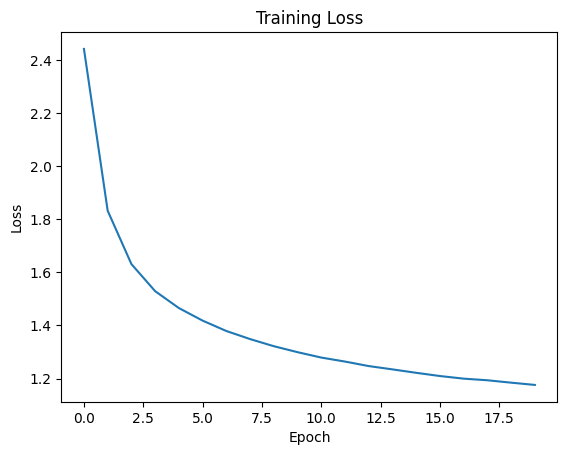

In [ ]:
plt.plot(history.history["loss"])

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.savefig("training_loss.png",dpi=300)

plt.show()

In [ ]:
!pip install gradio

import gradio as gr
import numpy as np

def generate_text(seed, length, temperature):

    result = seed.lower()

    for _ in range(length):

        seq = result[-seq_length:]

        x = np.array([[char_to_idx.get(c,0) for c in seq]])

        preds = model.predict(x, verbose=0)[0]

        preds = np.log(preds + 1e-8) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))

        next_index = np.random.choice(range(vocab_size), p=preds)
        next_char = idx_to_char[next_index]

        result += next_char

    return result


demo = gr.Interface(
    fn=generate_text,
    inputs=[
        gr.Textbox(label="Seed Text", value="the proposed method"),
        gr.Slider(100, 1000, value=400, step=50, label="Generation Length"),
        gr.Slider(0.2, 1.2, value=0.5, step=0.1, label="Temperature")
    ],
    outputs=gr.Textbox(label="Generated Research Text"),
    title="Research Paper Text Generator (LSTM)",
    description="Generate research-style text using an LSTM trained on Hugging Face trending papers."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://40fb9ad62ddcf8bc64.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
